## Importing the required madules

In [168]:
import torch
import torchvision
from torchvision.transforms import v2
import random
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

!pip install wandb
import wandb
wandb.login()

True

- Note all the pakage versions in the requirement.txt file

In [169]:
!pip freeze > requirements.txt

- Setting random seeds for all random operation and setting determinitic flags

In [170]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}")

Random seed set to 42


## a) Data loading and processing
- Defining transform and loading the CIFAR10 dataset

In [171]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

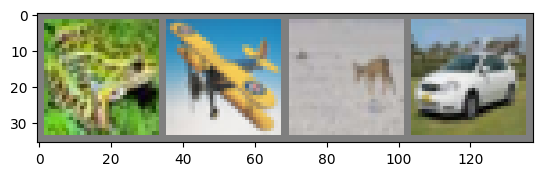

frog  plane deer  car  


In [172]:
# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## b) Model ArchitectureDefining 
- convolutional neural network

In [173]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

## c) Device and optimization setup

In [174]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cuda


In [175]:
net.to(device)

Net(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

### Defining optimiser and loss function

In [176]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## d) Training Loop Implementation
- defining a train function, becuase it can be used later for checkpointing.

In [178]:
def net_train_one_epoch(model, epoch, trainloader, optimizer, criterion):
    running_loss = 0.0
    total_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data[0].to(device), data[1].to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            total_loss += running_loss
            running_loss = 0.0

    print('Finished Training for epoch: ', epoch)
    return model, total_loss/len(trainloader)

- Starting the W&B run before the first training

In [179]:
run = wandb.init(
    project="cifar10-assessment",
    name="cnn_checkpoints",
    config={
        "dataset": "CIFAR10",
        "epochs_total": 16,
        "Learning_rate": 0.001,
        "batch_size": batch_size,
        "momentum": 0.9,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss"
    }
)

- Training the model for only one epoch

In [180]:
net, train_loss = net_train_one_epoch(
    net, 1, trainloader, optimizer, criterion
)

[1,  2000] loss: 2.163
[1,  4000] loss: 1.793
[1,  6000] loss: 1.607
[1,  8000] loss: 1.533
[1, 10000] loss: 1.458
[1, 12000] loss: 1.415
Finished Training for epoch:  1


## e) Evaluation and Metrics

### checking the network performance on whole test dataset
- defining an evalutaion function that is more suitable when needed to evaluation at checkpointing.

In [181]:
def net_eval(model, testloader, device):
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            # calculate outputs by running images through the network
            outputs = model(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            # Save labels and predictions
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    
    accuracy = 100 * correct // total
    print(f'Accuracy of the network on the 10000 test images: {accuracy} %')
    return accuracy, all_labels, all_predictions
   

In [182]:
test_accuracy, all_labels, all_predictions = net_eval(net, testloader, device)
#logging the metrics of first epoch by wandb
wandb.log({
    "train_loss": train_loss,
    "test_accuracy": test_accuracy
}, step=1)

Accuracy of the network on the 10000 test images: 50 %


- finding the model accuracy for each of the classes

In [183]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 60.6 %
Accuracy for class: car   is 49.5 %
Accuracy for class: bird  is 31.4 %
Accuracy for class: cat   is 8.7 %
Accuracy for class: deer  is 32.3 %
Accuracy for class: dog   is 71.1 %
Accuracy for class: frog  is 60.9 %
Accuracy for class: horse is 65.3 %
Accuracy for class: ship  is 50.7 %
Accuracy for class: truck is 73.8 %


#### Confusion Matrix creation

In [184]:
cm = confusion_matrix(all_labels, all_predictions)
print(cm)

[[606  24  71   3  26  21  18  33  96 102]
 [ 20 495   3  10   7  15   9  21  60 360]
 [ 68  13 314  16 104 253  86  83  22  41]
 [ 26   9  39  87  52 521 104  77  19  66]
 [ 30   6 132  13 323 213  84 160  14  25]
 [ 16   2  47  25  33 711  33 102  16  15]
 [  6  10  48  19  70 146 609  36   9  47]
 [ 17   3  17   7  34 221  14 653   6  28]
 [234  52  26   6   6  17  12  22 507 118]
 [ 30  83   2   6   5  24  22  55  35 738]]


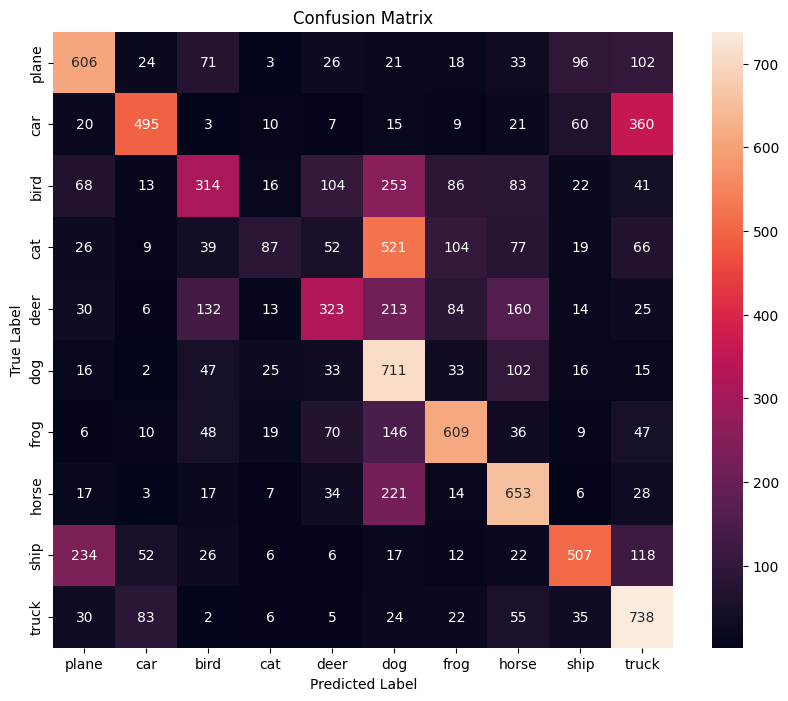

In [185]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

## f) Checkpointing and Model Persistence

- Saving the model as cifar_net.pt

In [187]:
PATH = './cifar_checkpoint_1.pth'
torch.save({
    'epoch': 1,
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'test_accuracy': test_accuracy,
}, PATH)

- Loading model

In [188]:
checkpoint = torch.load(PATH)

net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

test_accuracy = checkpoint['test_accuracy']
start_epoch = checkpoint["epoch"]


- Demonstrate short inference with reloaded model

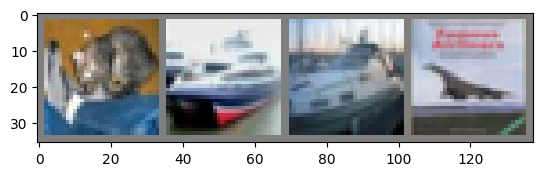

GroundTruth:  cat   ship  ship  plane
Predicted:  cat   ship  truck plane


In [189]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
outputs = net(images.to(device))
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

- finding the best model through 15 epochs

In [190]:
best_test_accuracy = test_accuracy
PATH = './cifar_best_model.pth'
for epoch in range(start_epoch, start_epoch+15):
    
    net, train_loss = net_train_one_epoch(
    net, epoch+1, trainloader, optimizer, criterion
    )
    test_accuracy, all_labels, all_predictions = net_eval(net, testloader, device)
    #logging the metrics by wandb
    wandb.log({
        "train_loss": train_loss,
        "test_accuracy": test_accuracy
    }, step=epoch + 1)
    if test_accuracy > best_test_accuracy:
        best_test_accuracy = test_accuracy
        torch.save({
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_accuracy': test_accuracy,
        }, PATH)
    

[2,  2000] loss: 1.319
[2,  4000] loss: 1.273
[2,  6000] loss: 1.267
[2,  8000] loss: 1.274
[2, 10000] loss: 1.227
[2, 12000] loss: 1.195
Finished Training for epoch:  2
Accuracy of the network on the 10000 test images: 57 %
[3,  2000] loss: 1.123
[3,  4000] loss: 1.129
[3,  6000] loss: 1.110
[3,  8000] loss: 1.090
[3, 10000] loss: 1.087
[3, 12000] loss: 1.059
Finished Training for epoch:  3
Accuracy of the network on the 10000 test images: 58 %
[4,  2000] loss: 0.999
[4,  4000] loss: 0.998
[4,  6000] loss: 0.991
[4,  8000] loss: 1.002
[4, 10000] loss: 1.000
[4, 12000] loss: 0.995
Finished Training for epoch:  4
Accuracy of the network on the 10000 test images: 62 %
[5,  2000] loss: 0.897
[5,  4000] loss: 0.926
[5,  6000] loss: 0.931
[5,  8000] loss: 0.913
[5, 10000] loss: 0.918
[5, 12000] loss: 0.945
Finished Training for epoch:  5
Accuracy of the network on the 10000 test images: 65 %
[6,  2000] loss: 0.859
[6,  4000] loss: 0.855
[6,  6000] loss: 0.878
[6,  8000] loss: 0.878
[6, 1000

In [191]:
artifact = wandb.Artifact("best-cifar10-model", type="model")

artifact.add_file("cifar_best_model.pth")

wandb.log_artifact(artifact)
wandb.finish()

test_accuracy,▁▄▄▆▇█▇█▇█▇████▇
train_loss,█▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁
test_accuracy,64
train_loss,0.58068


- Verfitying the saved best model

In [192]:
checkpoint = torch.load(PATH)

net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

test_accuracy = checkpoint['test_accuracy']

In [193]:
test_accuracy, all_labels, all_predictions = net_eval(net, testloader, device)
print(f"Test Accuracy from saved best model is {test_accuracy} and test accuracy from the training loop is {best_test_accuracy}")

Accuracy of the network on the 10000 test images: 67 %
Test Accuracy from saved best model is 67 and test accuracy from the training loop is 67


- Confussion matrix of the best model

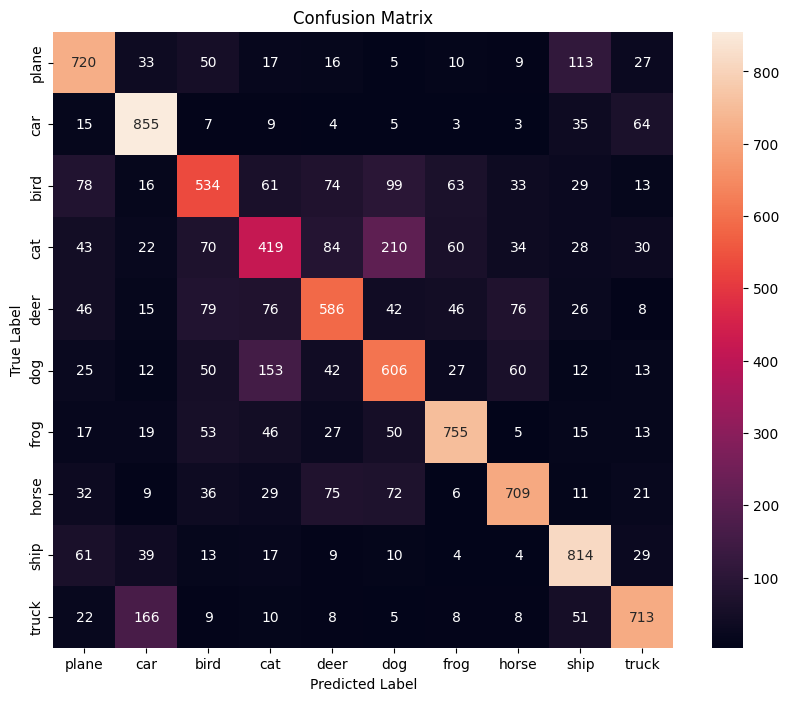

In [194]:
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

- List of prepared file in the Kaggle working directory

In [202]:
ls

cifar_best_model.pth  cifar_checkpoint_1.pth  data/  requirements.txt  wandb/
